Aprendizaje Automatico 1

Trabajo Práctico Nº 2

Integrantes: Quinteros, Lasarte, Lazarte

Columnas:


*   Date (Temporal): Fecha del registro (formato año-mes-día).
*   Location (Catagórica): Ciudad meteorológica donde se tomó la medición.
*   MinTemp (Numérica): Temperatura mínima del día (°C).
*   MaxTemp (Numérica): Temperatura máxima del día (°C).
*   Rainfall (Numérica): Cantidad de lluvia caída en el día (mm).
*   Evaporatio (Numérica): Cantidad de agua evaporada (mm).
*   Sunshine (Numérica): Horas de sol durante el día.
*   WindGustDir (Catagórica): Dirección de la ráfaga de viento más fuerte.
*   WindGustSpeed (Numérica): Velocidad máxima de ráfaga de viento (km/h).
*   WindDir9am (Catagórica): Dirección del viento a las 9 am.
*   WindDir3pm (Catagórica): Dirección del viento a las 3 pm.
*   WindSpeed9am (Numérica): Velocidad del viento a las 9 am.
*   WindSpeed3pm (Numérica): Velocidad del viento a las 3 pm.
*   Humidity9am (Numérica): Humedad relativa (%) a las 9 am.
*   Humidity3pm (Numérica): Humedad relativa (%) a las 3 pm.
*   Pressure9am (Numérica): Presión atmosférica (hPa) a las 9 am.
*   Pressure3pm (Numérica): Presión atmosférica (hPa) a las 3 pm.
*   Cloud9am (Numérica): Nubosidad a las 9 am (escala de 0 a 8, donde 8 es cielo totalmente cubierto).
*   Cloud3pm (Numérica): Nubosidad a las 3 pm.
*   Temp9am (Numérica): Temperatura medida a las 9 am.
*   Temp3pm (Numérica): Temperatura medida a las 3 pm.
*   RainToday (Catagórica): Indica si llovió ese día (Yes/No).
*   RainTomorrow (Catagórica): Indica si va a llover al día siguiente.
*   RainfallTomorrow (Numérica): Cantidad de lluvia del día siguiente (mm).



In [135]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [136]:
clima = pd.read_csv('weatherAUS_2026C1.csv')

In [137]:
clima.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [138]:
clima.info()

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  str    
 2   Location          145412 non-null  str    
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  str    
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  str    
 11  WindDir3pm        141186 non-null  str    
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       130351 non-nu

In [139]:
clima = clima.drop('Unnamed: 0', axis = 1) # Se borra porque es simplemente un índice (contador de filas). No aporta información meteorológica.

In [146]:
print("Cantidad de valores NaN:")
print(f"\n{clima.isnull().sum()}")

Cantidad de valores NaN:

Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60812
Sunshine         67785
WindGustDir       9328
WindGustSpeed     9268
WindDir9am       10009
WindDir3pm        3776
WindSpeed9am      1348
WindSpeed3pm      2629
Humidity9am       1774
Humidity3pm       3609
Pressure9am      14010
Pressure3pm      13977
Cloud9am         53641
Cloud3pm         57076
Temp9am            904
Temp3pm           2725
RainToday         1406
RainTomorrow         0
Month                0
Month_sin            0
Month_cos            0
dtype: int64


In [ ]:
#porcentaje de valores nulos por variable
print("\nPorcentaje de valores NaN:")
print(f"\n{(clima.isnull().sum() / len(clima)) * 100}")

In [140]:
#limpieza pre-split: sacamos columnas leakage, filas sin target y encodeamos
clima = clima.drop(columns=['RainfallTomorrow'])
clima = clima.dropna(subset=['RainTomorrow'])
clima['RainTomorrow'] = clima['RainTomorrow'].map({'No': 0, 'Yes': 1}).astype(int)

In [141]:
#extraemos month de Date y lo encodeamos cíclico para el modelo
clima['Date'] = pd.to_datetime(clima['Date'])
clima['Month'] = clima['Date'].dt.month
clima['Month_sin'] = np.sin(2 * np.pi * clima['Date'].dt.month / 12)
clima['Month_cos'] = np.cos(2 * np.pi * clima['Date'].dt.month / 12)
clima = clima.drop(columns=['Date'])

#Separamos features y targets
X = clima.drop(columns=['RainTomorrow'])
y = clima['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(113722, 24) (28431, 24)


Hacemos los boxplots sobre X_train para describir lo que el modelo va a ver. Si lo hiciesemos sobre todo el dataset, estariamos mirando informacion del test al hacer el analisis, lo que es una forma de leakage, ya que esto nos haria tomar decisiones sobre el preprocesamiento o el modelo basado en los datos del test.

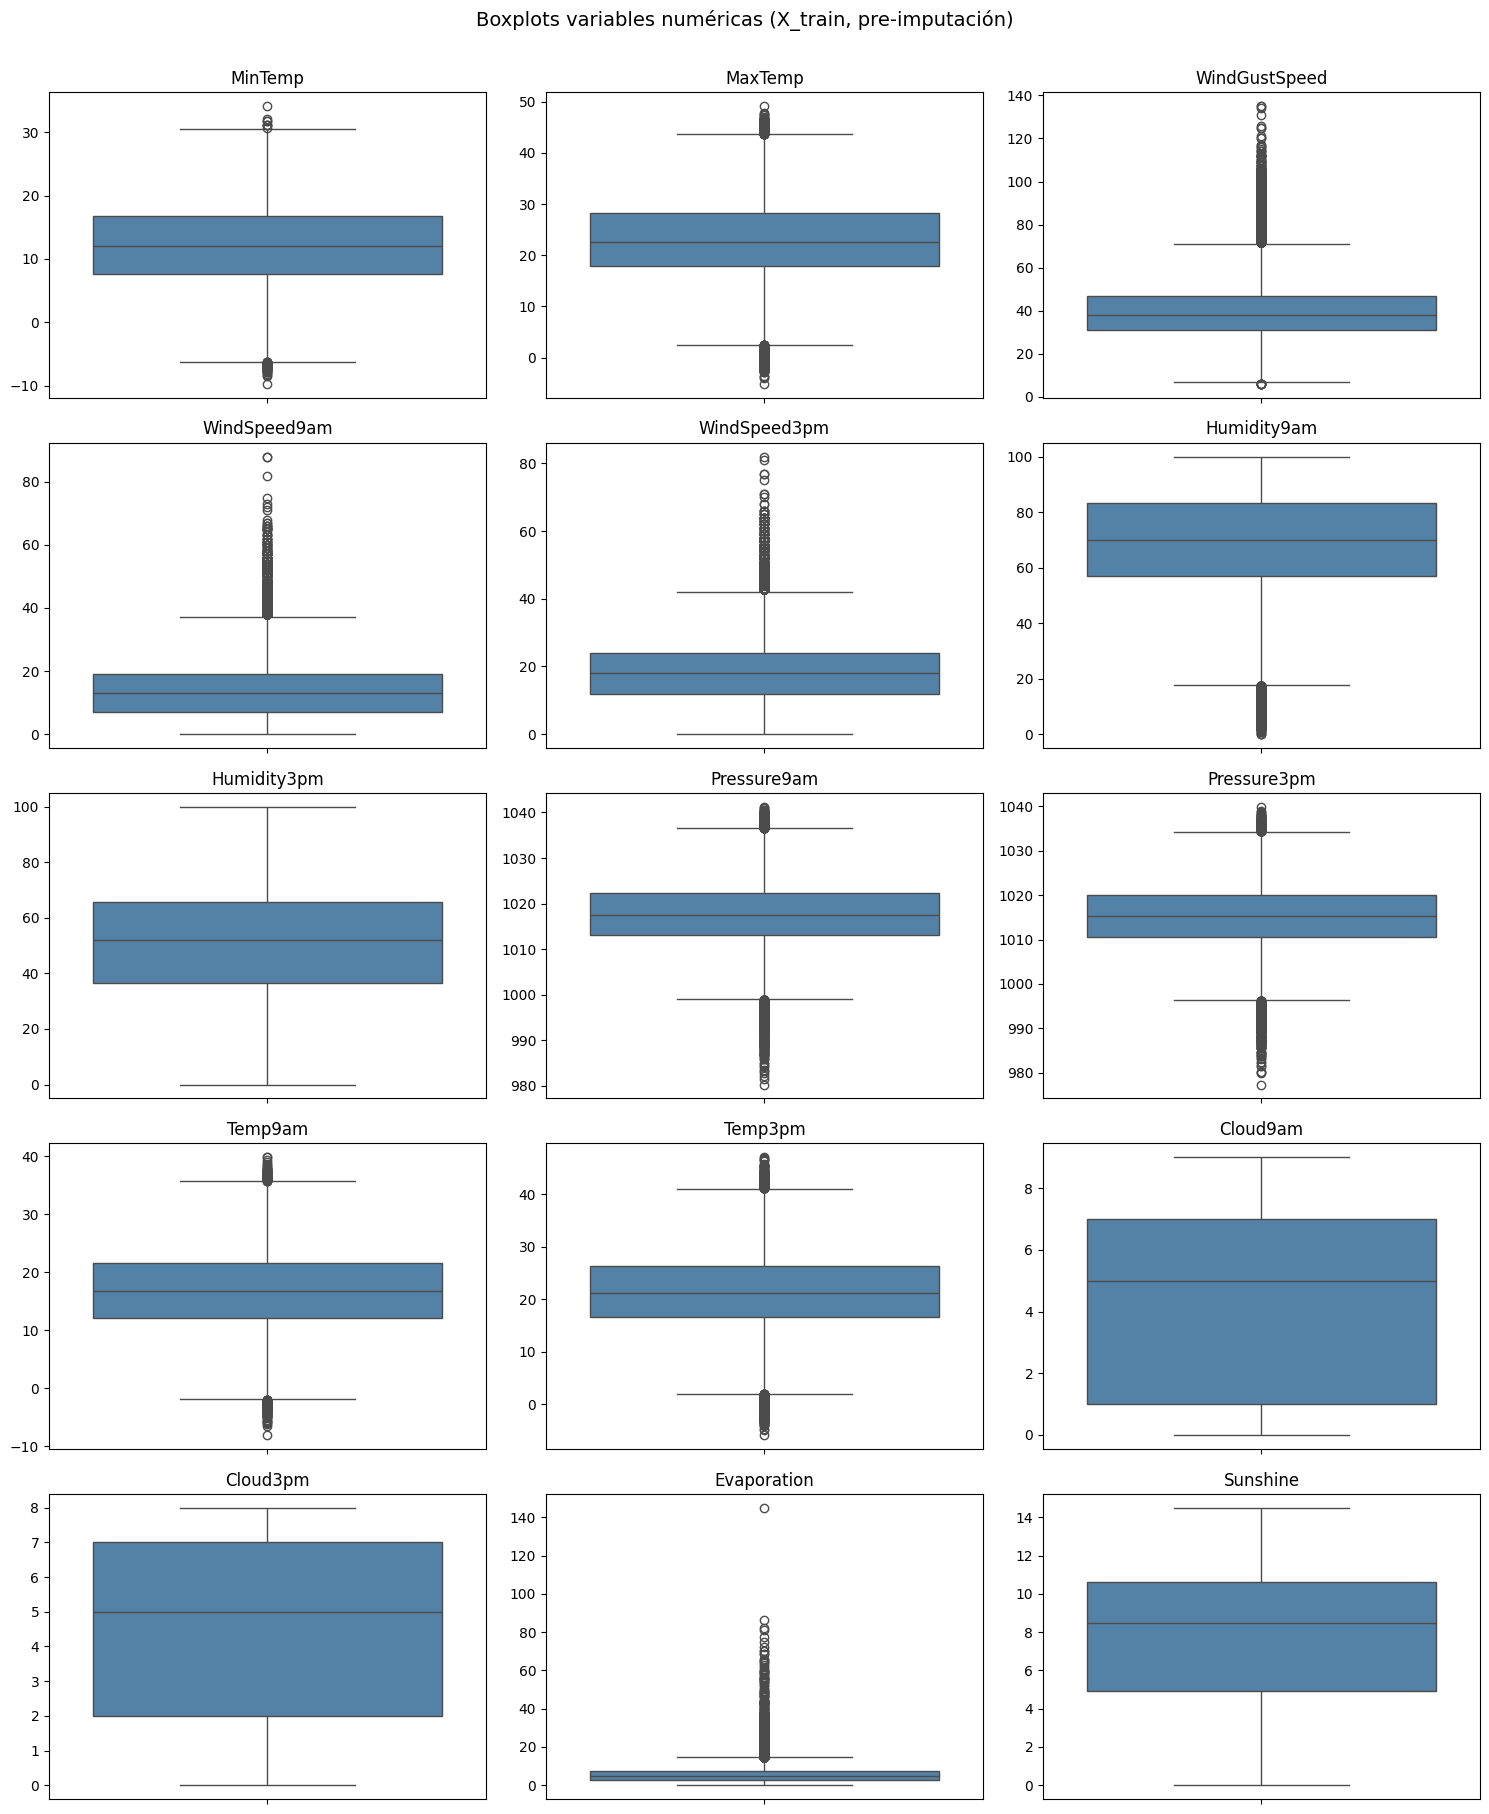

In [142]:
fig, axes = plt.subplots(5, 3, figsize=(15, 18))
for i, c in enumerate(vars_num):
    ax = axes[i // 3, i % 3]
    sns.boxplot(y=X_train[c], ax=ax, color='steelblue')   # ← X_train, no X1_train
    ax.set_title(c)
    ax.set_ylabel('')
plt.suptitle('Boxplots variables numéricas (X_train, pre-imputación)', fontsize=14, y=1.005)
plt.tight_layout()
plt.show()


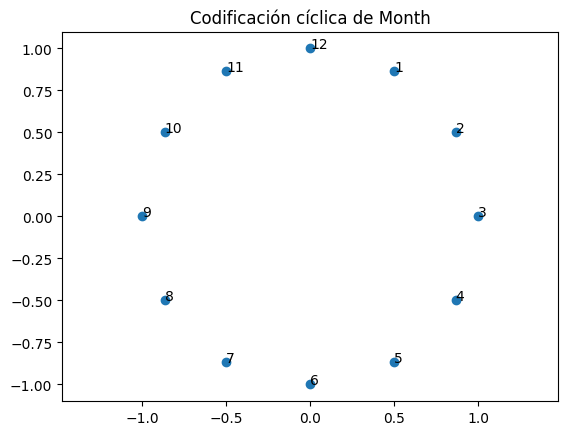

In [143]:
months_test = np.arange(1, 13)
plt.scatter(np.sin(2*np.pi*months_test/12), np.cos(2*np.pi*months_test/12))
for m in months_test:
    plt.annotate(str(m), (np.sin(2*np.pi*m/12), np.cos(2*np.pi*m/12)))
plt.title('Codificación cíclica de Month')
plt.axis('equal')
plt.show()


In [144]:
clima.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow,Month,Month_sin,Month_cos
count,141516.000000,141831.000000,140747.000000,81341.000000,74368.000000,132885.000000,140805.000000,139524.000000,140379.000000,138544.000000,128143.000000,128176.000000,88512.000000,85077.000000,141249.000000,139428.000000,142153.000000,142153.000000,1.421530e+05,1.421530e+05
mean,12.188866,23.228596,2.350461,5.470149,7.624919,39.985807,14.025219,18.636901,68.824619,51.475886,1017.651087,1015.257671,4.437014,4.503003,16.989044,21.687203,0.224209,6.402658,1.094909e-02,-1.617935e-02
std,6.422856,7.134436,8.466267,4.188649,3.781656,13.630314,8.914326,8.858849,19.085026,20.846540,7.112519,7.043730,2.887024,2.720623,6.513369,6.954501,0.417062,3.426981,7.053123e-01,7.086324e-01
min,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,0.000000,1.000000,-1.000000e+00,-1.000000e+00
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,12.000000,56.900000,36.500000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000,3.000000,-5.000000e-01,-8.660254e-01
50%,12.000000,22.600000,0.000000,4.800000,8.500000,38.000000,13.000000,18.000000,69.900000,51.900000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000,6.000000,1.224647e-16,-1.836970e-16
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.100000,65.600000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.000000,9.000000,5.000000e-01,5.000000e-01
max,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,130.000000,86.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,9.000000,39.800000,47.000000,1.000000,12.000000,1.000000e+00,1.000000e+00


Tratamiento de NaNs:



*   Rainfall: Reemplazamos NaN por 0. Asumimos que NaN significa "no se registró"
*   'RainToday': Se reemplazó NaN por 'No' (moda), codificamos a 1/0
*   RainTomorrow (target): eliminamos filas con NaN. No se puede entrenar contra un objetivo desconocido
*   RainfallTomorrow: Se elimina la columna ya que no se usa en el modelo ya que es el leakage en si
* Antes de imputar variables numericas, agregamos flags binarios para las columnas con alta proporcion de NaN. Porque una vez imputados los NaNs se pierde la distincion. Por lo tanto permite que el modelo preserve la informacion de que valores fueron imputados
- Categoricas:
*   WindGustDir, WindDir9am, WindDir3pm: Imputamos en cascada de 3 niveles porque hay algunas combinaciones que no tienen datos suficientes en train. Imputamos de mas especifico a menos (location, month) -> (location) -> (moda global)
 Los estadísticos se calculan solo con X_train para evitar leakage, y se aplican a X_test.

- Numericas: 
*   MinTemp, MaxTemp, WindGustSpeed, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Temp9am, Temp3pm, Cloud9am, Cloud3pm: Reemplazamos con la misma cascada pero con la mediana debido a outliers
* Evaporation y Sunshine: tienen un gran porcentaje de NaN (>40%) por lo tanto probamos 2 estrategias para luego comparar:
    - clima 1: conservamos variables e imputamos por cascada + flag
    - clima 2: las eliminamos junto con sus flags

En el item 2 entrenamos la regresion logistica sobre los datasets para ver cual estrategia generaliza mejor

* Location y month: los usamos solo como agrupadores para imputar.
    - Motivos de 'Location': no hacer one-hot encoding sobre las 49 ciudades. Algunas aparecen pocas veces.
    - Motivos 'month: ya creamos dos features nuevas que codifican la posicion del mes ciclicamente



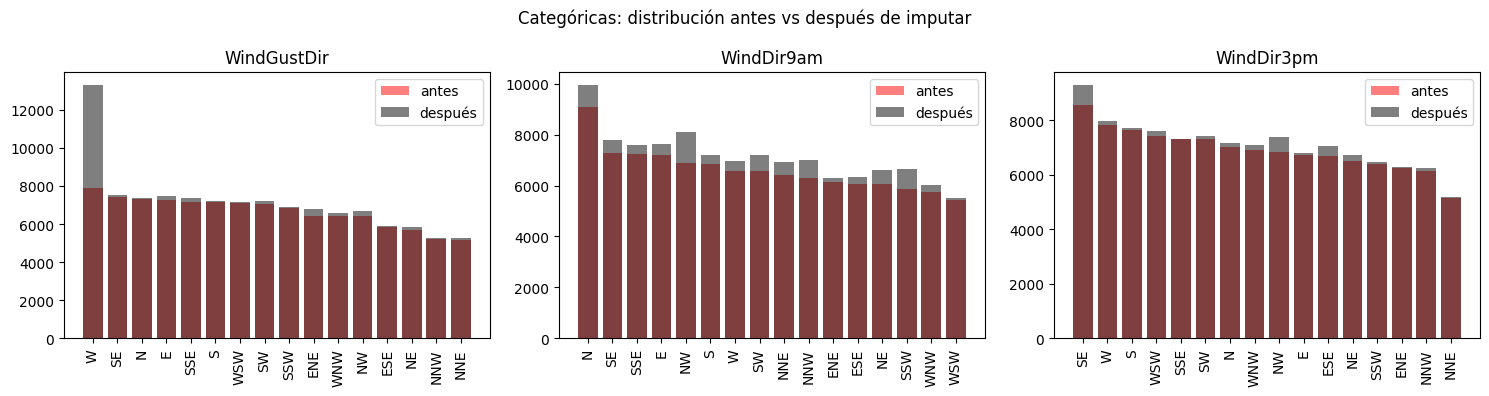

clima1: (113722, 77) (28431, 77) | NaN: 0 0
clima2: (113722, 73) (28431, 73) | NaN: 0 0


In [133]:
# Imputación con leakage fix
# Cascada (Location, Month) → Location → global, fit solo en X_train

X1_train = X_train.copy()
X1_test = X_test.copy()

#1 Imputaciones constantes (no requieren stats del dataset)
for X in [X1_train, X1_test]:
    X['Rainfall'] = X['Rainfall'].fillna(0)        #Como no esta registrado (NaN), asumimos 0 mm
    X['RainToday'] = X['RainToday'].fillna('No')   #lo  mismo para rain today

#2 creamos Flags _missing antes de imputar (preservan info de "fue NaN")
cols_flag = ['Humidity9am','Humidity3pm','Pressure9am','Pressure3pm',
             'Temp9am','Temp3pm','Cloud9am','Cloud3pm','Evaporation','Sunshine']
for c in cols_flag:
    X1_train[c + '_missing'] = X1_train[c].isna().astype(int)
    X1_test[c + '_missing'] = X1_test[c].isna().astype(int)

#3 funcion auxiliar: cascada (Location, Month) → Location → global
def imputar_cascada(X, col, stat_loc_month, stat_loc, stat_global):
    keys = pd.MultiIndex.from_arrays([X['Location'].values, X['Month'].values])
    vals = stat_loc_month.reindex(keys).values
    X[col] = X[col].fillna(pd.Series(vals, index=X.index))
    X[col] = X[col].fillna(X['Location'].map(stat_loc))
    X[col] = X[col].fillna(stat_global)

#4 imputamos Categóricas: moda con cascada (stats calculadas en X1_train)
for c in ['WindGustDir','WindDir9am','WindDir3pm']:
    moda_global = X1_train[c].mode(dropna=True).iloc[0]
    modas_loc = X1_train.groupby('Location')[c].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else moda_global)
    modas_loc_month = X1_train.groupby(['Location','Month'])[c].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    for X in [X1_train, X1_test]:
        imputar_cascada(X, c, modas_loc_month, modas_loc, moda_global)

#5 Numéricas: mediana con cascada (stats calculadas en X1_train)
cols_num = ['MinTemp','MaxTemp','WindGustSpeed','WindSpeed9am','WindSpeed3pm',
            'Humidity9am','Humidity3pm','Pressure9am','Pressure3pm',
            'Temp9am','Temp3pm','Cloud9am','Cloud3pm','Evaporation','Sunshine']
for c in cols_num:
    med_global = X1_train[c].median()
    meds_loc = X1_train.groupby('Location')[c].median()
    meds_loc_month = X1_train.groupby(['Location','Month'])[c].median()
    for X in [X1_train, X1_test]:
        imputar_cascada(X, c, meds_loc_month, meds_loc, med_global)

#6 Encodeamos RainToday para el modelo lineal Yes/No → 1/0
for X in [X1_train, X1_test]:
    X['RainToday'] = X['RainToday'].map({'Yes': 1, 'No': 0}).astype(int)

#7 Dropeamos Location y Month (porque ya cumplieron su rol como agrupadores). 
#Las variables metereologicas ya capturan el efecto local, y month ya lo tenemos como feature ciclica
#solo las utilizamos para agrupar y no para el modelo
X1_train = X1_train.drop(columns=['Location','Month'])
X1_test  = X1_test.drop(columns=['Location','Month'])

#8 Variante clima2: realizamos la misma imputación pero sin Evap/Sun ni sus flags
X2_train = X1_train.drop(columns=['Evaporation','Sunshine','Evaporation_missing','Sunshine_missing'])
X2_test  = X1_test.drop(columns=['Evaporation','Sunshine','Evaporation_missing','Sunshine_missing'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, c in enumerate(['WindGustDir', 'WindDir9am', 'WindDir3pm']):
    antes = X_train[c].value_counts(dropna=True)
    despues = X1_train[c].value_counts(dropna=True)

    ax = axes[i]
    x = range(len(antes))
    ax.bar(x, antes.values, alpha=0.5, color='red', label='antes')
    ax.bar(x, despues.reindex(antes.index).values, alpha=0.5, color='black', label='después')
    ax.set_xticks(x)
    ax.set_xticklabels(antes.index, rotation=90)
    ax.set_title(c)
    ax.legend()

plt.suptitle('Categóricas: distribución antes vs después de imputar')
plt.tight_layout()
plt.show()

# 9. One-hot consistente: dummies sobre train, reindex test con las columnas de train
#como las direcciones del viento son categoricas, las convertimos en columnas binarias
X1_train = pd.get_dummies(X1_train, columns=['WindGustDir','WindDir9am','WindDir3pm'])
X1_test  = pd.get_dummies(X1_test,  columns=['WindGustDir','WindDir9am','WindDir3pm'])
#por si el test no tiene hay alguna direccion que si este en el set de entrenamiento 
X1_test  = X1_test.reindex(columns=X1_train.columns, fill_value=0)

X2_train = pd.get_dummies(X2_train, columns=['WindGustDir','WindDir9am','WindDir3pm'])
X2_test  = pd.get_dummies(X2_test,  columns=['WindGustDir','WindDir9am','WindDir3pm'])
X2_test  = X2_test.reindex(columns=X2_train.columns, fill_value=0)

# Verificamos
print('clima1:', X1_train.shape, X1_test.shape, '| NaN:', X1_train.isnull().sum().sum(), X1_test.isnull().sum().sum())
print('clima2:', X2_train.shape, X2_test.shape, '| NaN:', X2_train.isnull().sum().sum(), X2_test.isnull().sum().sum())

Notamos que WindGustDir luego de la imputacion se concentra en W. Esto sugiere que en la cascada de imputacion la mayoria cayó al nivel 3. Debido a que algunas combinaciones (location, month) no tienen datos suficientes. Sostenemos que mantener la columna es la mejor opcion ya que es una variable imporatante de prediccion ya que la direccion junto con otras variables se pueden asociar con precipitaciones

In [101]:
print("Cantidad de valores NaN:")
print(f"\n{X1_train.isnull().sum()}")

Cantidad de valores NaN:

MinTemp           0
MaxTemp           0
Rainfall          0
Evaporation       0
Sunshine          0
                 ..
WindDir3pm_SSW    0
WindDir3pm_SW     0
WindDir3pm_W      0
WindDir3pm_WNW    0
WindDir3pm_WSW    0
Length: 77, dtype: int64


In [102]:
X1_test.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Humidity9am_missing,Humidity3pm_missing,Pressure9am_missing,Pressure3pm_missing,Temp9am_missing,Temp3pm_missing,Cloud9am_missing,Cloud3pm_missing,Evaporation_missing,Sunshine_missing
count,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,...,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000
mean,12.252052,23.294568,2.279209,5.167302,8.082918,39.971281,14.034452,18.599328,68.818049,51.430776,...,0.012205,0.024375,0.095635,0.095072,0.006226,0.018255,0.378179,0.400162,0.425521,0.473392
std,6.404800,7.141904,7.925567,3.245260,2.856740,13.207054,8.913141,8.875466,19.013404,20.780403,...,0.109802,0.154213,0.294095,0.293320,0.078658,0.133874,0.484941,0.489940,0.494431,0.499300
min,-7.600000,-3.800000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.700000,18.000000,0.000000,3.600000,7.500000,31.000000,7.000000,12.000000,57.000000,36.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12.100000,22.700000,0.000000,4.800000,8.500000,38.000000,13.000000,18.000000,69.700000,51.900000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.900000,28.300000,0.800000,5.800000,9.500000,47.000000,19.000000,24.000000,82.900000,65.400000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,31.600000,46.900000,240.000000,64.000000,14.100000,125.000000,130.000000,86.000000,100.000000,100.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [103]:
print("Cantidad de valores NaN:")
print(f"\n{X2_train.isnull().sum()}")

Cantidad de valores NaN:

MinTemp           0
MaxTemp           0
Rainfall          0
WindGustSpeed     0
WindSpeed9am      0
                 ..
WindDir3pm_SSW    0
WindDir3pm_SW     0
WindDir3pm_W      0
WindDir3pm_WNW    0
WindDir3pm_WSW    0
Length: 73, dtype: int64


In [104]:
X2_train.describe()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,Month_sin,Month_cos,Humidity9am_missing,Humidity3pm_missing,Pressure9am_missing,Pressure3pm_missing,Temp9am_missing,Temp3pm_missing,Cloud9am_missing,Cloud3pm_missing
count,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,...,1.137220e+05,1.137220e+05,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000,113722.000000
mean,12.176261,23.212866,2.339215,39.868847,13.993977,18.559276,68.963402,51.573510,1017.665657,1015.267891,...,1.037876e-02,-1.813121e-02,0.012548,0.025641,0.099286,0.099136,0.006393,0.019398,0.377139,0.401848
std,6.424803,7.129094,8.548378,13.201408,8.884956,8.825494,19.079893,20.741929,6.753929,6.692538,...,7.055942e-01,7.083143e-01,0.111314,0.158064,0.299047,0.298847,0.079699,0.137920,0.484672,0.490274
min,-9.700000,-5.100000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,...,-1.000000e+00,-1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.600000,17.900000,0.000000,31.000000,7.000000,12.000000,57.000000,36.700000,1013.500000,1011.000000,...,-5.000000e-01,-8.660254e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12.000000,22.600000,0.000000,38.000000,13.000000,18.000000,70.100000,52.200000,1017.600000,1015.200000,...,1.224647e-16,-1.836970e-16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.800000,28.200000,0.600000,47.000000,19.000000,24.000000,83.200000,65.700000,1021.900000,1019.500000,...,5.000000e-01,5.000000e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,34.100000,49.100000,371.000000,135.000000,88.000000,82.000000,100.000000,100.000000,1041.200000,1039.800000,...,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


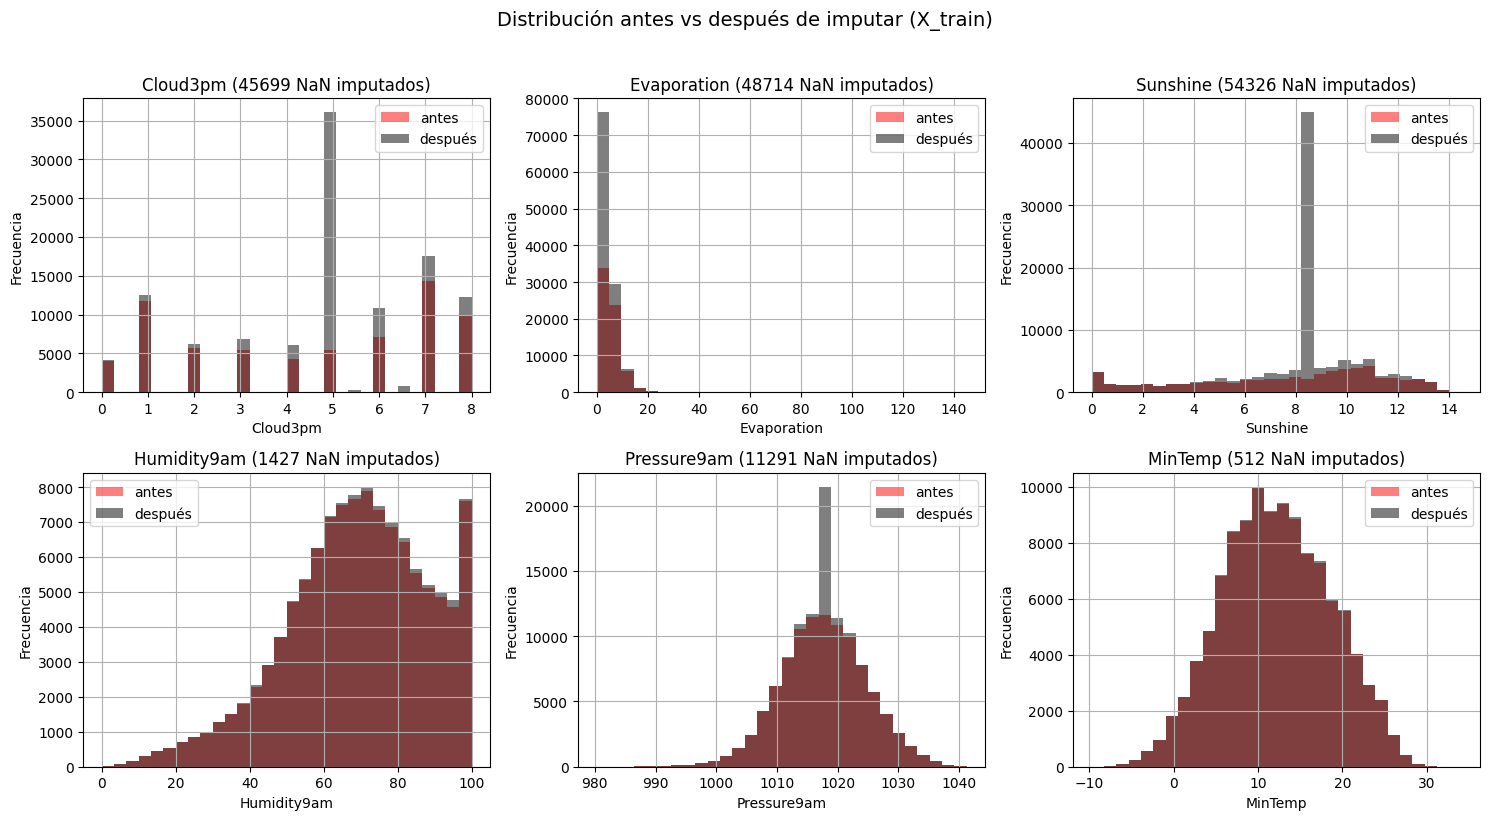

In [116]:
# QA visual: comparar distribuciones antes vs después de imputar (en X_train)
# Usamos las variables más afectadas por NaN para ver si la imputación las distorsionó

vars_num = ['Cloud3pm', 'Evaporation', 'Sunshine', 'Humidity9am', 'Pressure9am', 'MinTemp']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, c in enumerate(vars_num):
    ax = axes[i // 3, i % 3]
    X_train[c].dropna().hist(ax=ax, bins=30, alpha=0.5, color='red', label='antes')
    X1_train[c].hist(ax=ax, bins=30, alpha=0.5, color='black', label='después')
    ax.set_title(f'{c} ({X_train[c].isna().sum()} NaN imputados)')
    ax.set_xlabel(c)
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.suptitle('Distribución antes vs después de imputar (X_train)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

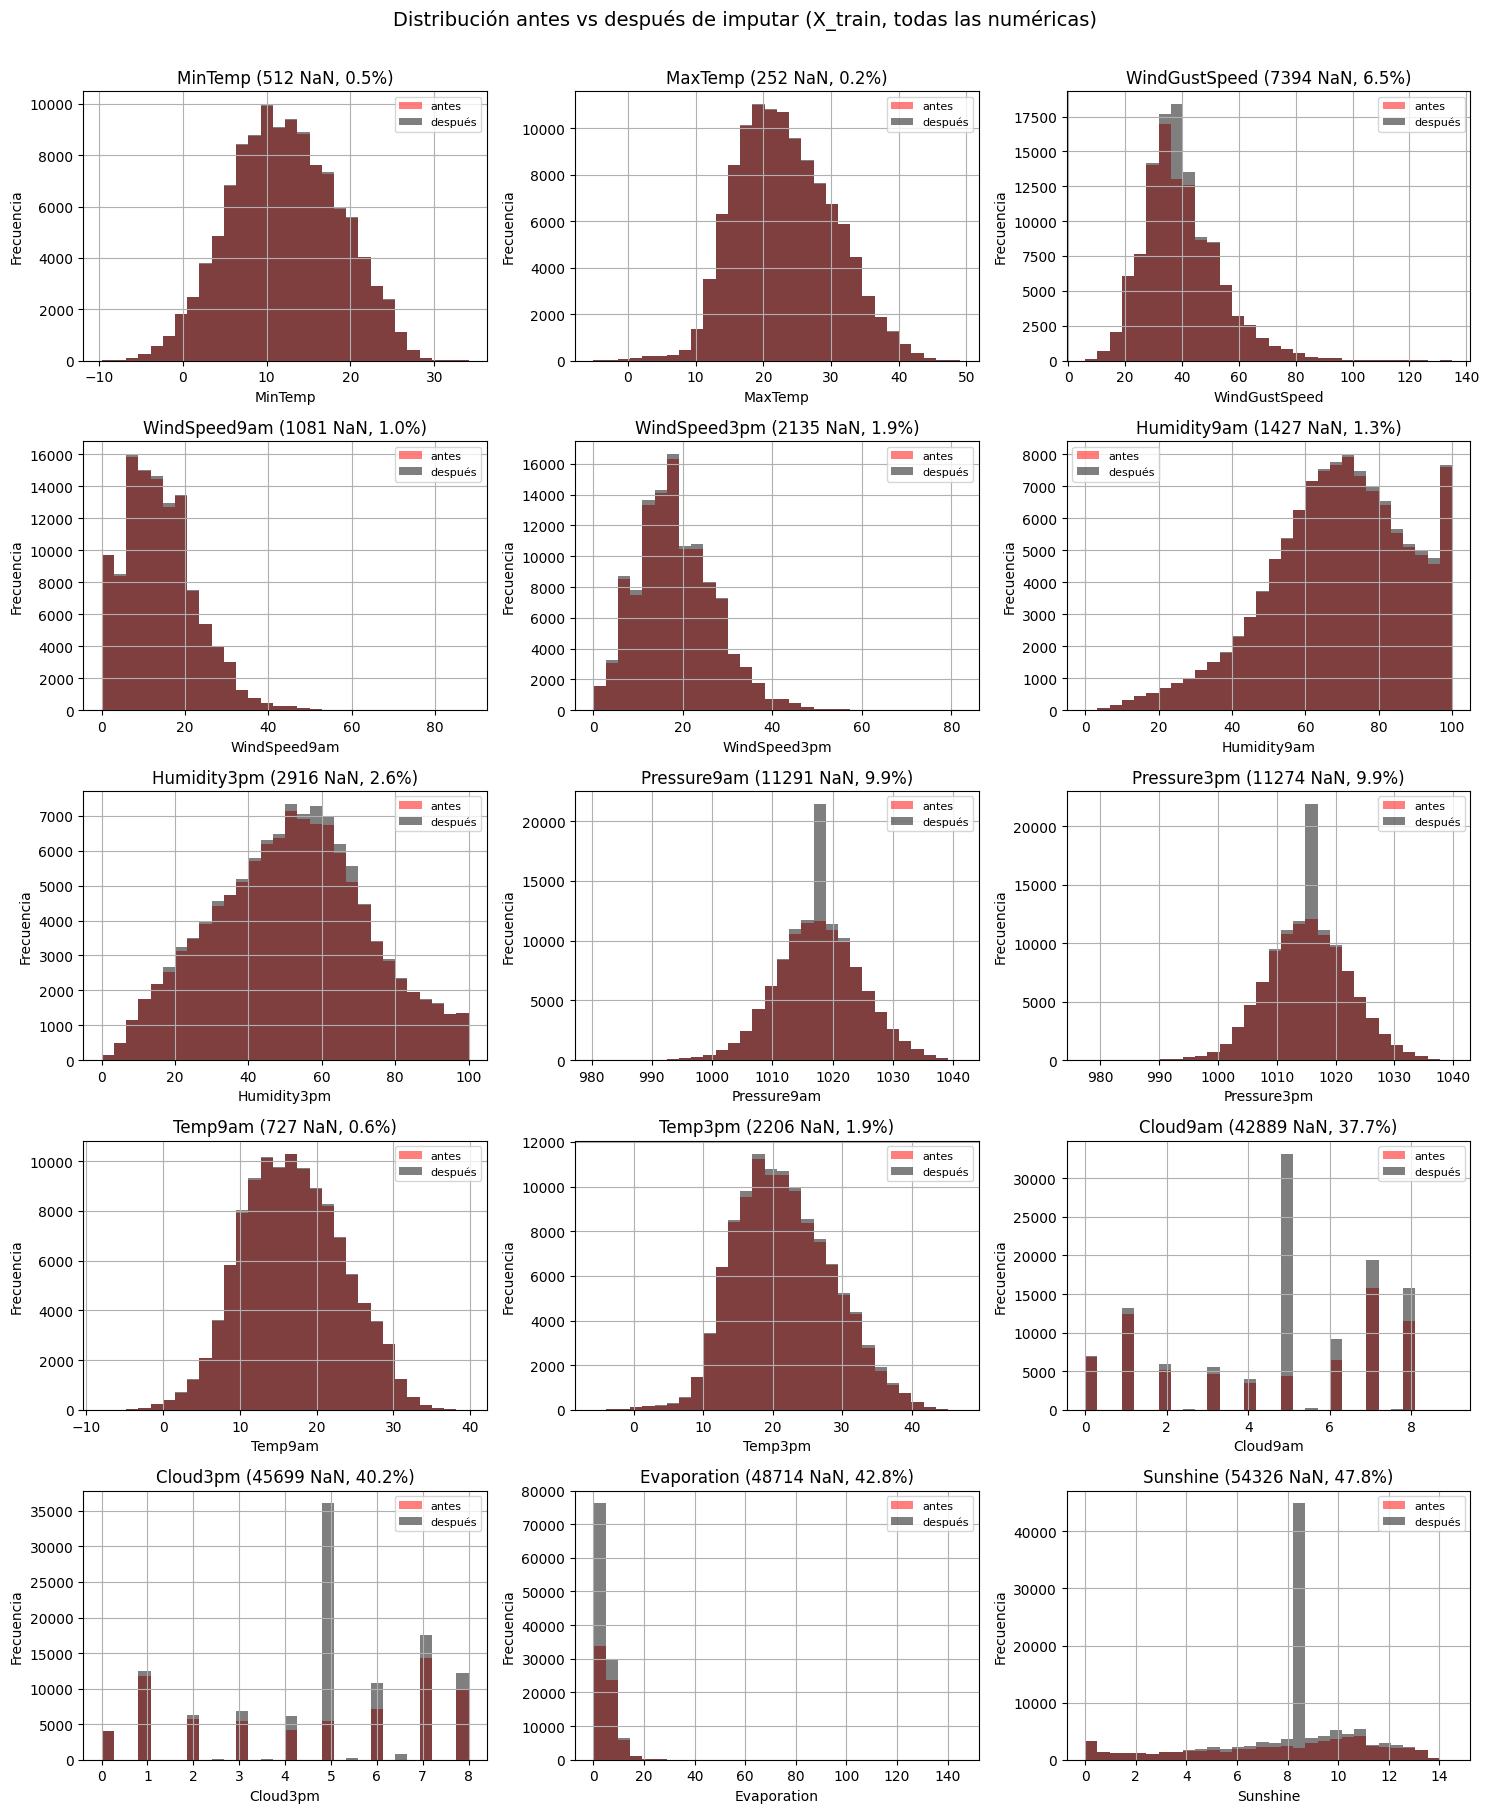

In [ ]:
#comparar distribuciones antes vs después de imputar (X_train)
#para todas las variables numéricas que pasaron por la cascada

vars_num = ['MinTemp', 'MaxTemp', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
            'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
            'Temp9am', 'Temp3pm', 'Cloud9am', 'Cloud3pm', 'Evaporation', 'Sunshine']

fig, axes = plt.subplots(5, 3, figsize=(15, 18))

for i, c in enumerate(vars_num):
    ax = axes[i // 3, i % 3]
    X_train[c].dropna().hist(ax=ax, bins=30, alpha=0.5, color='red', label='antes')
    X1_train[c].hist(ax=ax, bins=30, alpha=0.5, color='black', label='después')
    n_imp = X_train[c].isna().sum()
    pct = round(100 * n_imp / len(X_train), 1)
    ax.set_title(f'{c} ({n_imp} NaN, {pct}%)')
    ax.set_xlabel(c)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución antes vs después de imputar (X_train, todas las numéricas)',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.show()


podemos ver el antes y el despues de las imputaciones. 
 * las variables con bajo % de NaN las distribuciones se mantienen practicamente iguales
 * Para 'Sunshine' y 'Evaporation' con >40% de NaN, se nota claramente la concentracion en la mediana.
Por esto es que evaluamos clima2 como alternativa sin esas variables

In [108]:

conteo = df1['RainTomorrow'].value_counts()
porcentaje = df1['RainTomorrow'].value_counts(normalize=True) * 100

print("Conteo:")
print(conteo)

print("\nPorcentaje:")
print(porcentaje)

Conteo:
RainTomorrow
0    110281
1     31872
Name: count, dtype: int64

Porcentaje:
RainTomorrow
0    77.579087
1    22.420913
Name: proportion, dtype: float64


In [109]:

conteo = df2['RainTomorrow'].value_counts()
porcentaje = df2['RainTomorrow'].value_counts(normalize=True) * 100

print("Conteo:")
print(conteo)

print("\nPorcentaje:")
print(porcentaje)

Conteo:
RainTomorrow
0    110281
1     31872
Name: count, dtype: int64

Porcentaje:
RainTomorrow
0    77.579087
1    22.420913
Name: proportion, dtype: float64


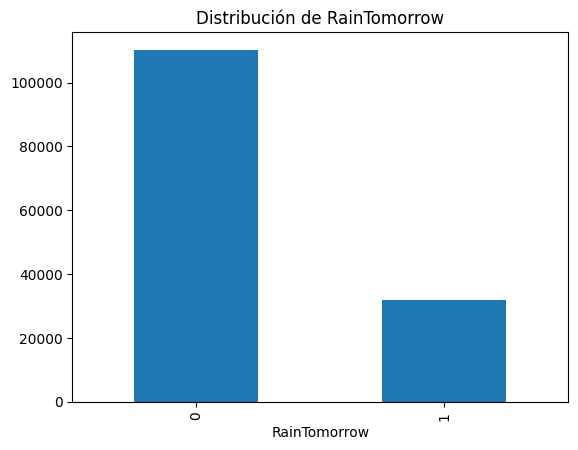

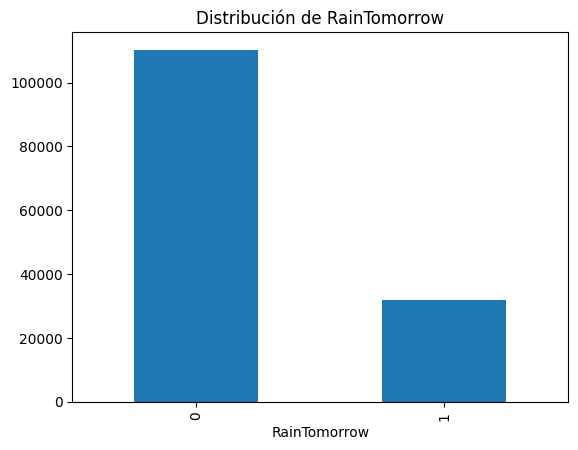

In [110]:
df1['RainTomorrow'].value_counts().plot(kind='bar')
plt.title('Distribución de RainTomorrow')
plt.show()

df2['RainTomorrow'].value_counts().plot(kind='bar')
plt.title('Distribución de RainTomorrow')
plt.show()

El Dataset está claramente desbalanceado, por lo que se deberá solucionar este problema más adelante

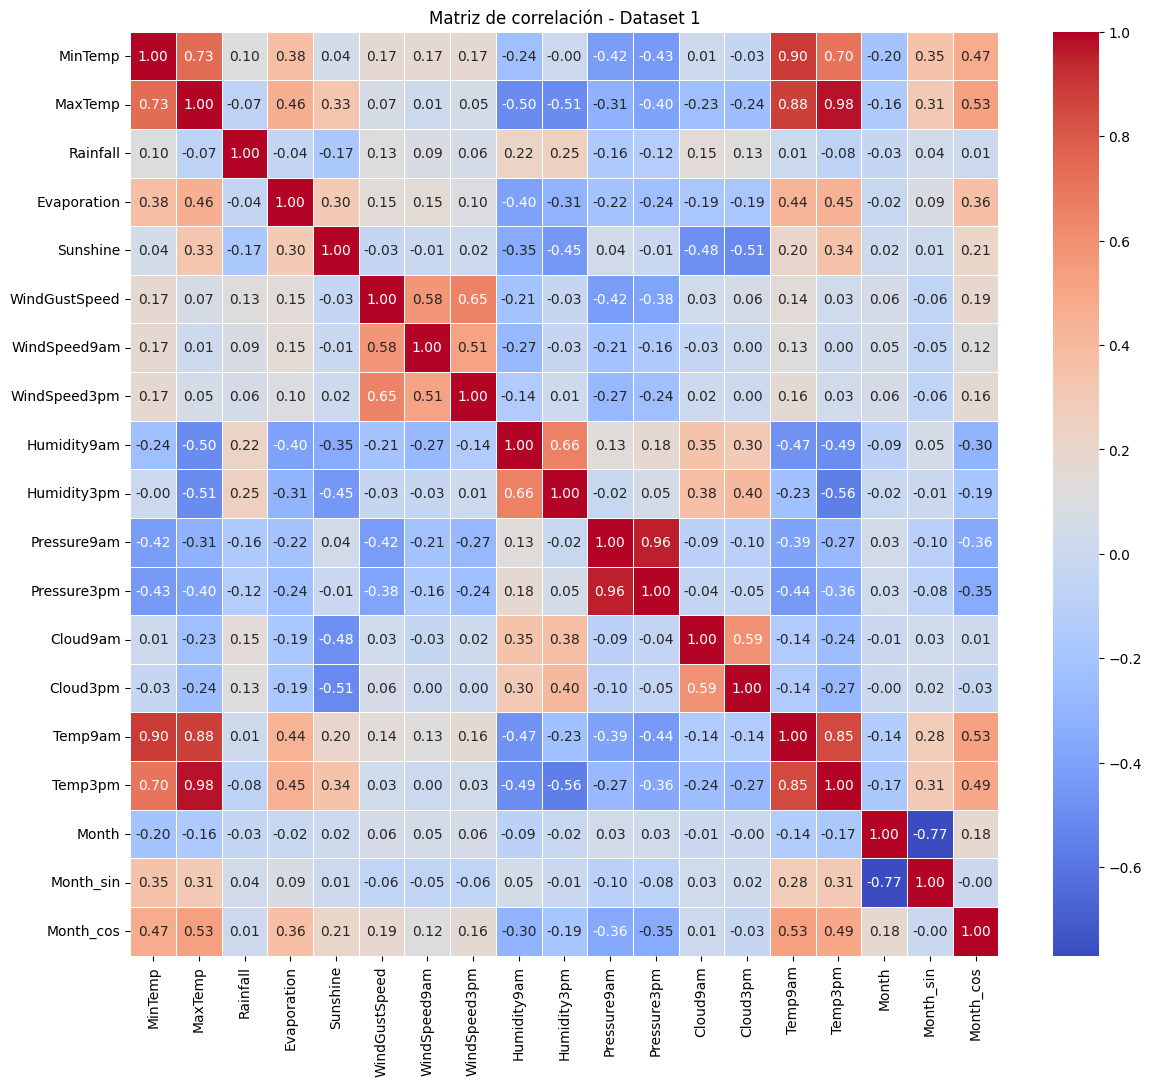

FileNotFoundError: [Errno 2] No such file or directory: 'dataset_sin_evap_sun.csv'

In [111]:

# Filtrar las columnas que no necesitamos para la correlación
df1_filtered = df1[[c for c in df1.columns
           if not c.endswith('_missing')
           and not c.startswith('WindGustDir_')
           and not c.startswith('WindDir9am_')
           and not c.startswith('WindDir3pm_')
           and c not in ['Date', 'Location', 'RainToday', 'RainTomorrow'] # Excluir categóricas y de identificación
           and df1[c].dtype != 'object'
]].copy()

corr1 = df1_filtered.corr(numeric_only=True)

plt.figure(figsize=(14, 12)) # Aumentar el tamaño de la figura
sns.heatmap(corr1, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5) # Usar seaborn.heatmap con anotaciones
plt.title('Matriz de correlación - Dataset 1')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

df2 = pd.read_csv('dataset_sin_evap_sun.csv')

# Filtrar las columnas que no necesitamos para la correlación
df2_filtered = df2[[c for c in df2.columns
           if not c.endswith('_missing')
           and not c.startswith('WindGustDir_')
           and not c.startswith('WindDir9am_')
           and not c.startswith('WindDir3pm_')
           and c not in ['Date', 'Location', 'RainToday', 'RainTomorrow'] # Excluir categóricas y de identificación
           and df2[c].dtype != 'object'
]].copy()

corr2 = df2_filtered.corr(numeric_only=True)

plt.figure(figsize=(12, 10)) # Aumentar el tamaño de la figura
sns.heatmap(corr2, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5) # Usar seaborn.heatmap con anotaciones
plt.title('Matriz de correlación - Dataset 2')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

Division Train/Test **la hacemos mas arriba para evitar data leakage** BORRAR

In [ ]:
df1 = pd.read_csv('dataset_imputado.csv')

X1 = df1.drop(columns=['RainTomorrow'])
y1 = df1['RainTomorrow']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

print(X1_train.shape, X1_test.shape)

(113722, 77) (28431, 77)


In [ ]:
df2 = pd.read_csv('dataset_sin_evap_sun.csv')

X2 = df2.drop(columns=['RainTomorrow'])
y2 = df2['RainTomorrow']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print(X2_train.shape, X2_test.shape)

(113722, 73) (28431, 73)


Escalado

In [ ]:

y = df['RainTomorrow']
X = df.drop(columns=['RainTomorrow'])

# Identificar columnas binarias (que ya están en formato 0 o 1)
cols_binarias = [c for c in X.columns if set(X[c].dropna().unique()).issubset({0,1})]

# Identificar columnas categóricas que necesitan codificación one-hot (además de las ya codificadas)
cols_categoricas_a_procesar = [c for c in X.columns if X[c].dtype == 'object' and c not in ['Date', 'Location']]

# Codificar las columnas categóricas
X = pd.get_dummies(X, columns=cols_categoricas_a_procesar, drop_first=True)

# Actualizar la lista de columnas numéricas
cols_numericas = [c for c in X.columns if X[c].dtype in ['int64', 'float64'] and c not in cols_binarias and c not in ['Date', 'Location']]

# Excluir 'Date' y 'Location' del escalado
X_to_scale = X[cols_numericas]
X_not_to_scale = X.drop(columns=cols_numericas + ['Date', 'Location'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_to_scale)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_to_scale.columns, index=X.index)

# Recombinar el DataFrame
X_final = pd.concat([X_scaled_df, X_not_to_scale], axis=1)

df_escalado = pd.concat([X_final, y], axis=1)

print(df_escalado.head())

    MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
0  0.219513 -0.102201 -0.204950     -0.10318  0.160839       0.387273   
1 -0.762595  0.360678 -0.276146     -0.10318  0.160839       0.311457   
2  0.157157  0.416785 -0.276146     -0.10318  0.160839       0.463088   
3 -0.341691  0.781478 -0.276146     -0.10318  0.160839      -1.280669   
4  0.811896  1.286437 -0.157487     -0.10318  0.160839       0.084011   

   WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  ...  WindDir3pm_NW  \
0      0.562490      0.729481    -0.006051    -1.341863  ...          False   
1     -1.124943      0.502710    -1.514976    -1.424083  ...          False   
2      0.674986      0.956251    -1.720022    -0.969458  ...          False   
3     -0.449969     -0.971299    -1.215294    -1.598194  ...          False   
4     -0.899952     -0.177602     0.766814    -0.819528  ...           True   

   WindDir3pm_S  WindDir3pm_SE  WindDir3pm_SSE  WindDir3pm_SSW  WindDir3pm_SW  \
0    

In [ ]:
df = pd.read_csv('dataset_sin_evap_sun.csv')

y = df['RainTomorrow']
X = df.drop(columns=['RainTomorrow'])

# Identificar columnas binarias (que ya están en formato 0 o 1)
cols_binarias = [c for c in X.columns if set(X[c].dropna().unique()).issubset({0,1})]

# Identificar columnas categóricas que necesitan codificación one-hot (además de las ya codificadas)
cols_categoricas_a_procesar = [c for c in X.columns if X[c].dtype == 'object' and c not in ['Date', 'Location']]

# Codificar las columnas categóricas
X = pd.get_dummies(X, columns=cols_categoricas_a_procesar, drop_first=True)

# Actualizar la lista de columnas numéricas
cols_numericas = [c for c in X.columns if X[c].dtype in ['int64', 'float64'] and c not in cols_binarias and c not in ['Date', 'Location']]

# Excluir 'Date' y 'Location' del escalado
X_to_scale = X[cols_numericas]
X_not_to_scale = X.drop(columns=cols_numericas + ['Date', 'Location'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_to_scale)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_to_scale.columns, index=X.index)

# Recombinar el DataFrame
X_final = pd.concat([X_scaled_df, X_not_to_scale], axis=1)

df_escalado = pd.concat([X_final, y], axis=1)

print(df_escalado.head())

    MinTemp   MaxTemp  Rainfall  WindGustSpeed  WindSpeed9am  WindSpeed3pm  \
0  0.219513 -0.102201 -0.204950       0.387273      0.562490      0.729481   
1 -0.762595  0.360678 -0.276146       0.311457     -1.124943      0.502710   
2  0.157157  0.416785 -0.276146       0.463088      0.674986      0.956251   
3 -0.341691  0.781478 -0.276146      -1.280669     -0.449969     -0.971299   
4  0.811896  1.286437 -0.157487       0.084011     -0.899952     -0.177602   

   Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  ...  WindDir3pm_NW  \
0    -0.006051    -1.341863    -1.412798    -1.203450  ...          False   
1    -1.514976    -1.424083    -0.968644    -1.158604  ...          False   
2    -1.720022    -0.969458    -1.531239    -0.874584  ...          False   
3    -1.215294    -1.598194    -0.006309    -0.426130  ...          False   
4     0.766814    -0.819528    -0.998254    -1.397780  ...           True   

   WindDir3pm_S  WindDir3pm_SE  WindDir3pm_SSE  WindDir3pm_SSW  Wind